In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Configuration
dataset_path = r"C:\Users\manis\OneDrive\Desktop\plant-disease\plantvillage_dataset\color"
img_size = (180, 180)  
epochs = 5
batch_size = 8


In [5]:
disease_solutions = {
    "Apple___Apple_scab": {
        "symptoms": "Dark, scabby lesions on leaves and fruit",
        "causes": "Fungal infection (Venturia inaequalis)",
        "solutions": [
            "Apply fungicides containing myclobutanil or captan",
            "Remove fallen leaves and debris",
            "Improve air circulation around trees",
            "Use resistant apple varieties",
            "Apply sulfur-based fungicides in early spring"
        ],
        "prevention": "Regular pruning, proper spacing, and sanitation"
    },
    "Apple___Black_rot": {
        "symptoms": "Brown to black circular lesions on fruit and leaves",
        "causes": "Fungal infection (Botryosphaeria obtusa)",
        "solutions": [
            "Remove infected plant material immediately",
            "Apply copper-based fungicides",
            "Improve drainage and air circulation",
            "Prune to remove dead wood",
            "Use captan or thiophanate-methyl fungicides"
        ],
        "prevention": "Proper sanitation and regular monitoring"
    },
    "Apple___Cedar_apple_rust": {
        "symptoms": "Yellow-orange spots on leaves, galls on cedar trees",
        "causes": "Fungal infection (Gymnosporangium juniperi-virginianae)",
        "solutions": [
            "Remove nearby cedar trees if possible",
            "Apply fungicides containing myclobutanil",
            "Use resistant apple varieties",
            "Apply sulfur fungicides in early spring",
            "Improve air circulation"
        ],
        "prevention": "Plant resistant varieties and maintain distance from cedar trees"
    },
    "Apple___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering schedule",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning schedule"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Blueberry___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Cherry_(including_sour)___Powdery_mildew": {
        "symptoms": "White powdery growth on leaves and fruit",
        "causes": "Fungal infection (Podosphaera clandestina)",
        "solutions": [
            "Apply sulfur-based fungicides",
            "Prune to improve air circulation",
            "Remove infected plant material",
            "Use resistant varieties",
            "Avoid overhead watering"
        ],
        "prevention": "Proper spacing and regular monitoring"
    },
    "Cherry_(including_sour)___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": {
        "symptoms": "Gray to tan rectangular lesions on leaves",
        "causes": "Fungal infection (Cercospora zeae-maydis)",
        "solutions": [
            "Apply fungicides containing azoxystrobin",
            "Use resistant varieties",
            "Practice crop rotation",
            "Remove crop debris",
            "Improve air circulation"
        ],
        "prevention": "Crop rotation and resistant varieties"
    },
    "Corn_(maize)___Common_rust_": {
        "symptoms": "Orange to brown pustules on leaves",
        "causes": "Fungal infection (Puccinia sorghi)",
        "solutions": [
            "Apply fungicides containing propiconazole",
            "Use resistant varieties",
            "Remove crop debris",
            "Improve air circulation",
            "Apply copper fungicides"
        ],
        "prevention": "Use resistant varieties and proper field sanitation"
    },
    "Corn_(maize)___Northern_Leaf_Blight": {
        "symptoms": "Long, tan lesions with dark borders",
        "causes": "Fungal infection (Exserohilum turcicum)",
        "solutions": [
            "Apply fungicides containing azoxystrobin",
            "Use resistant varieties",
            "Practice crop rotation",
            "Remove crop debris",
            "Improve air circulation"
        ],
        "prevention": "Crop rotation and resistant varieties"
    },
    "Corn_(maize)___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper field management"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Grape___Black_rot": {
        "symptoms": "Black spots on leaves, stems, and fruit",
        "causes": "Fungal infection (Guignardia bidwellii)",
        "solutions": [
            "Apply fungicides containing myclobutanil",
            "Remove infected plant material",
            "Prune to improve air circulation",
            "Use resistant varieties",
            "Practice crop rotation"
        ],
        "prevention": "Proper sanitation and regular monitoring"
    },
    "Grape___Esca_(Black_Measles)": {
        "symptoms": "Leaf discoloration, black streaks on wood",
        "causes": "Fungal infection (Phaeomoniella chlamydospora)",
        "solutions": [
            "Remove infected wood",
            "Apply fungicides",
            "Improve drainage",
            "Use resistant varieties",
            "Avoid wounding vines"
        ],
        "prevention": "Proper pruning and sanitation"
    },
    "Grape___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": {
        "symptoms": "Brown spots with yellow halos on leaves",
        "causes": "Fungal infection (Isariopsis griseola)",
        "solutions": [
            "Apply fungicides containing copper",
            "Remove infected leaves",
            "Improve air circulation",
            "Use resistant varieties",
            "Practice crop rotation"
        ],
        "prevention": "Proper sanitation and regular monitoring"
    },
    "Orange___Haunglongbing_(Citrus_greening)": {
        "symptoms": "Yellow shoots, blotchy mottling of leaves",
        "causes": "Bacterial infection (Candidatus Liberibacter spp.)",
        "solutions": [
            "Remove infected trees",
            "Control psyllid vectors",
            "Use disease-free planting material",
            "Apply foliar sprays",
            "Monitor regularly"
        ],
        "prevention": "Use certified disease-free plants and control vectors"
    },
    "Peach___Bacterial_spot": {
        "symptoms": "Dark, sunken spots on fruit and leaves",
        "causes": "Bacterial infection (Xanthomonas campestris pv. pruni)",
        "solutions": [
            "Apply copper-based bactericides",
            "Remove infected plant material",
            "Improve air circulation",
            "Use resistant varieties",
            "Practice crop rotation"
        ],
        "prevention": "Proper sanitation and regular monitoring"
    },
    "Peach___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Pepper,_bell___Bacterial_spot": {
        "symptoms": "Small, water-soaked spots on leaves and fruit",
        "causes": "Bacterial infection (Xanthomonas campestris pv. vesicatoria)",
        "solutions": [
            "Apply copper-based bactericides",
            "Remove infected plant material",
            "Improve air circulation",
            "Use disease-free seeds",
            "Practice crop rotation"
        ],
        "prevention": "Use certified disease-free seeds and proper spacing"
    },
    "Pepper,_bell___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Potato___Early_blight": {
        "symptoms": "Dark, concentric rings on leaves",
        "causes": "Fungal infection (Alternaria solani)",
        "solutions": [
            "Apply fungicides containing chlorothalonil",
            "Remove infected leaves",
            "Improve air circulation",
            "Use resistant varieties",
            "Practice crop rotation"
        ],
        "prevention": "Crop rotation and proper plant spacing"
    },
    "Potato___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Potato___Late_blight": {
        "symptoms": "Water-soaked lesions, white mold on leaves",
        "causes": "Fungal infection (Phytophthora infestans)",
        "solutions": [
            "Apply fungicides containing chlorothalonil",
            "Remove infected plants immediately",
            "Improve air circulation",
            "Use resistant varieties",
            "Practice crop rotation"
        ],
        "prevention": "Avoid overhead watering and use resistant varieties"
    },
    "Raspberry___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Soybean___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Squash___Powdery_mildew": {
        "symptoms": "White powdery growth on leaves",
        "causes": "Fungal infection (Podosphaera xanthii)",
        "solutions": [
            "Apply sulfur-based fungicides",
            "Remove infected leaves",
            "Improve air circulation",
            "Use resistant varieties",
            "Avoid overhead watering"
        ],
        "prevention": "Proper spacing and regular monitoring"
    },
    "Strawberry___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Strawberry___Leaf_scorch": {
        "symptoms": "Dark brown spots with yellow halos on leaves",
        "causes": "Fungal infection (Diplocarpon earlianum)",
        "solutions": [
            "Apply fungicides containing captan",
            "Remove infected leaves",
            "Improve air circulation",
            "Use resistant varieties",
            "Practice crop rotation"
        ],
        "prevention": "Proper sanitation and regular monitoring"
    },
    "Tomato___Bacterial_spot": {
        "symptoms": "Small, dark spots on leaves, stems, and fruit",
        "causes": "Bacterial infection (Xanthomonas spp.)",
        "solutions": [
            "Apply copper-based bactericides",
            "Remove infected plant material",
            "Improve air circulation",
            "Use disease-free seeds",
            "Apply streptomycin if available"
        ],
        "prevention": "Use certified disease-free seeds and proper spacing"
    },
    "Tomato___Early_blight": {
        "symptoms": "Concentric rings on leaves, stem lesions",
        "causes": "Fungal infection (Alternaria solani)",
        "solutions": [
            "Apply chlorothalonil or mancozeb fungicides",
            "Remove infected leaves",
            "Improve air circulation",
            "Use drip irrigation",
            "Apply copper fungicides"
        ],
        "prevention": "Crop rotation and proper plant spacing"
    },
    "Tomato___healthy": {
        "symptoms": "No visible disease symptoms",
        "causes": "Healthy plant",
        "solutions": [
            "Continue current care practices",
            "Maintain regular watering",
            "Apply balanced fertilizer",
            "Monitor for early signs of disease",
            "Maintain proper pruning"
        ],
        "prevention": "Continue preventive care and monitoring"
    },
    "Tomato___Late_blight": {
        "symptoms": "Water-soaked lesions, white mold on leaves",
        "causes": "Fungal infection (Phytophthora infestans)",
        "solutions": [
            "Apply fungicides containing chlorothalonil",
            "Remove infected plants immediately",
            "Improve air circulation",
            "Use resistant varieties",
            "Apply copper fungicides preventively"
        ],
        "prevention": "Avoid overhead watering and use resistant varieties"
    },
    "Tomato___Leaf_Mold": {
        "symptoms": "Yellow spots on upper leaf surface, mold on underside",
        "causes": "Fungal infection (Passalora fulva)",
        "solutions": [
            "Improve air circulation",
            "Reduce humidity",
            "Apply fungicides containing chlorothalonil",
            "Remove infected leaves",
            "Use resistant varieties"
        ],
        "prevention": "Proper ventilation and humidity control"
    },
    "Tomato___Septoria_leaf_spot": {
        "symptoms": "Small, circular spots with dark borders",
        "causes": "Fungal infection (Septoria lycopersici)",
        "solutions": [
            "Apply fungicides containing chlorothalonil",
            "Remove infected leaves",
            "Improve air circulation",
            "Use drip irrigation",
            "Apply copper fungicides"
        ],
        "prevention": "Crop rotation and proper sanitation"
    },
    "Tomato___Spider_mites Two-spotted_spider_mite": {
        "symptoms": "Yellow stippling on leaves, fine webbing",
        "causes": "Spider mite infestation (Tetranychus urticae)",
        "solutions": [
            "Apply insecticidal soap or neem oil",
            "Introduce predatory mites",
            "Increase humidity",
            "Use miticides containing abamectin",
            "Remove heavily infested leaves"
        ],
        "prevention": "Regular monitoring and maintaining proper humidity"
    },
    "Tomato___Target_Spot": {
        "symptoms": "Concentric rings on leaves and fruit",
        "causes": "Fungal infection (Corynespora cassiicola)",
        "solutions": [
            "Apply fungicides containing chlorothalonil",
            "Remove infected plant material",
            "Improve air circulation",
            "Use resistant varieties",
            "Apply copper fungicides"
        ],
        "prevention": "Proper plant spacing and air circulation"
    },
    "Tomato___Tomato_mosaic_virus": {
        "symptoms": "Mottled yellow and green patterns on leaves",
        "causes": "Viral infection (Tobacco mosaic virus)",
        "solutions": [
            "Remove infected plants immediately",
            "Use virus-free seeds",
            "Control aphid vectors",
            "Disinfect tools between plants",
            "Plant resistant varieties"
        ],
        "prevention": "Use certified virus-free seeds and control vectors"
    },
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": {
        "symptoms": "Yellowing and curling of leaves, stunted growth",
        "causes": "Viral infection (TYLCV)",
        "solutions": [
            "Remove infected plants",
            "Control whitefly vectors",
            "Use resistant varieties",
            "Apply systemic insecticides",
            "Use reflective mulches"
        ],
        "prevention": "Use resistant varieties and control whitefly vectors"
    }
}

In [6]:
# Verify dataset path exists
if not os.path.exists(dataset_path):
    print(f"ERROR: Dataset path '{dataset_path}' does not exist!")
    print("Please check your dataset path and try again.")
    exit(1)

In [7]:
# Use ImageDataGenerator for memory efficiency
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    validation_split=0.2
)

In [8]:
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    subset='validation',
    shuffle=False
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [9]:
class_names = list(train_gen.class_indices.keys())
print(f"Found {len(class_names)} classes: {class_names}")


Found 38 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

In [12]:

# Create model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*img_size, 3)
)
base_model.trainable = False
model = models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(len(class_names), activation='softmax')
])

In [13]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,718,068 (29.44 MB)

 Trainable params: 2,327,462 (8.88 MB)

 Non-trainable params: 735,680 (2.81 MB)

 Optimizer params: 4,654,926 (17.76 MB)

In [11]:
# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    ),
    callbacks.ModelCheckpoint(
        'detector_disease.keras',
        monitor='val_accuracy',
        save_best_only=True,
        save_freq = 'epoch',
        verbose=1
    )
]

In [ ]:
# Train model
history = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // batch_size,
    epochs=epochs,
    validation_data=val_gen,
    validation_steps=val_gen.samples // batch_size,
    callbacks=callbacks_list,
    verbose=1
)


In [ ]:
# Fine-tuning
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_fine = model.fit(
    train_gen,
    steps_per_epoch=train_gen.samples // batch_size,
    epochs=5,
    validation_data=val_gen,
    validation_steps=val_gen.samples // batch_size,
    callbacks=callbacks_list,
    verbose=1
)


In [14]:
from tensorflow.keras.models import load_model
model = load_model(r'C:\Users\manis\OneDrive\Desktop\plant-disease\models\detector_disease.keras')

In [16]:
# Evaluate model
val_gen.reset()
val_steps = val_gen.samples // batch_size
val_preds = model.predict(val_gen, steps=val_steps, verbose=1)
y_pred_classes = np.argmax(val_preds, axis=1)
y_true_classes = val_gen.classes[:val_steps * batch_size]


1356/1356 ━━━━━━━━━━━━━━━━━━━━ 191s 141ms/step


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.99      0.98       126
                                 Apple___Black_rot       0.98      1.00      0.99       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       0.99      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.91      0.86       102
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.89      0.

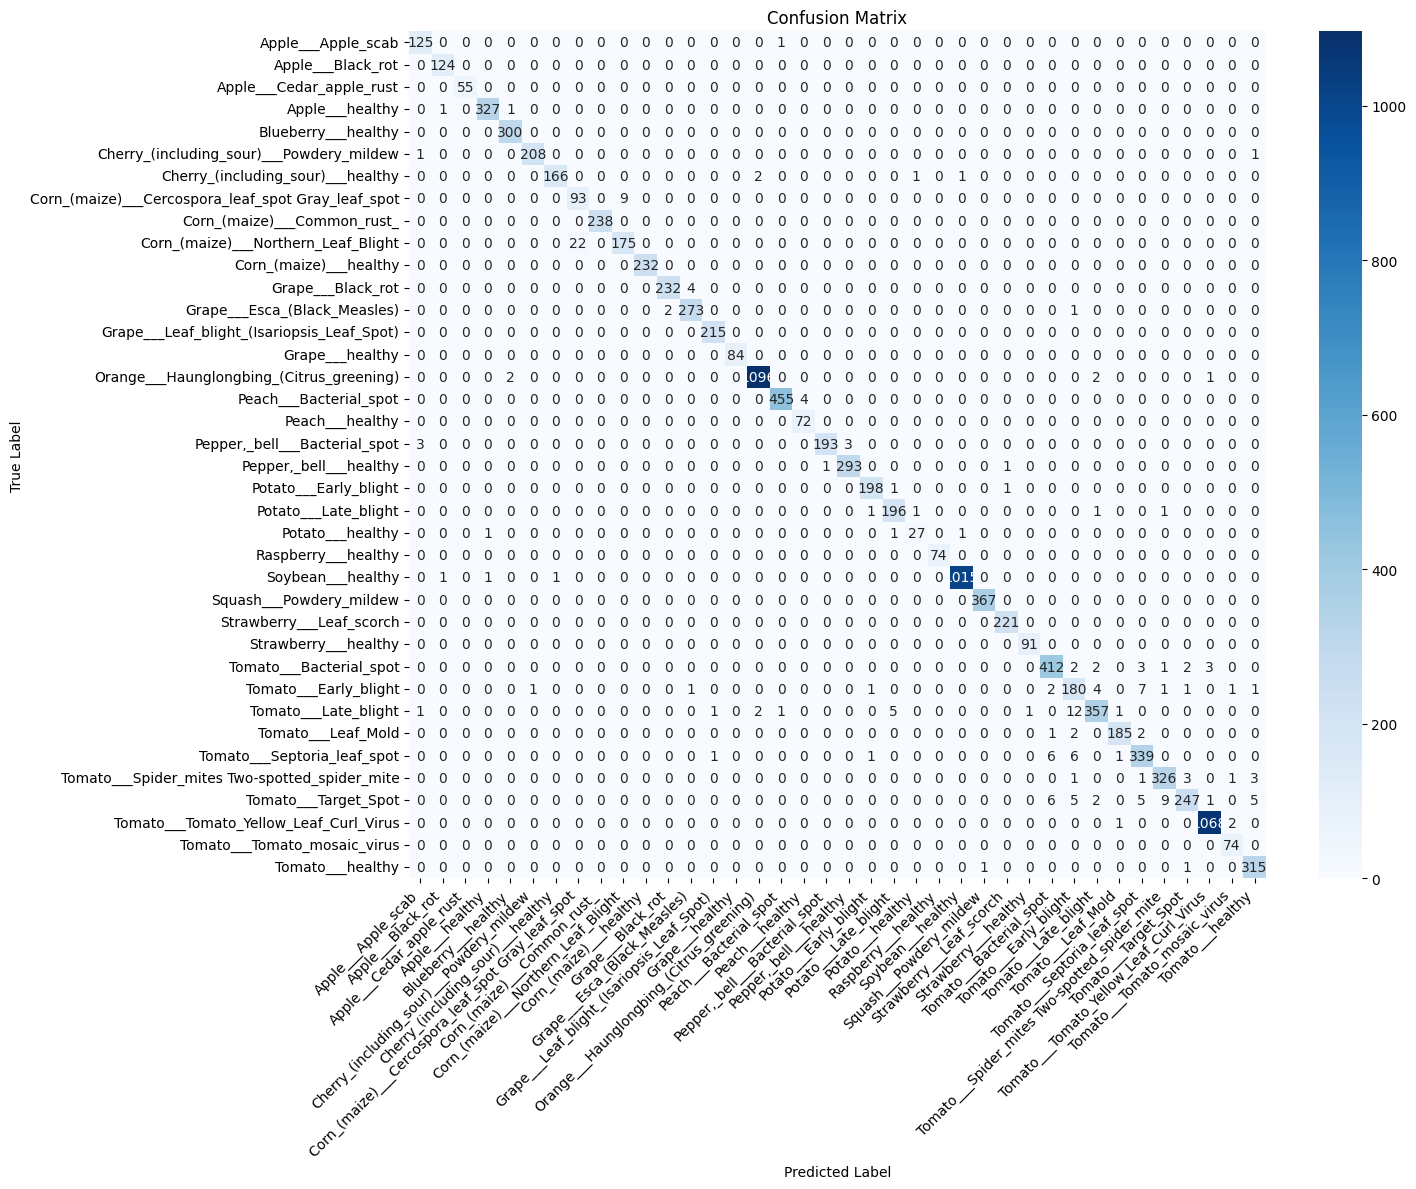

In [18]:
# Classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png')



In [19]:
# Save model
model.save('detector_disease.keras')

NameError: name 'history_fine' is not defined

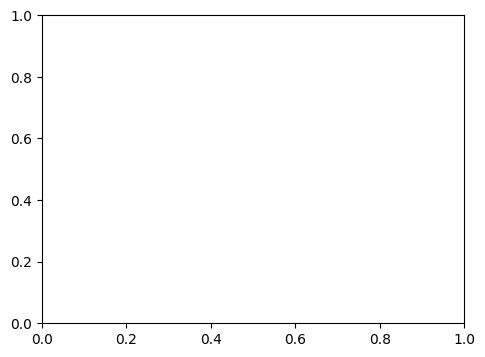

In [20]:

# Plot fine-tuning training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_history.png')

In [21]:
val_loss, test_accuracy = model.evaluate(val_gen, steps=val_gen.samples // batch_size, verbose=1)
print(f"Final Test Accuracy: {test_accuracy:.4f} ")


1356/1356 ━━━━━━━━━━━━━━━━━━━━ 128s 93ms/step - accuracy: 0.9823 - loss: 0.0544
Final Test Accuracy: 0.9823 


In [34]:
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"❌ Dataset path not found: {dataset_path}")
else :
    print(f"✅ Dataset path found: {dataset_path}") 

✅ Dataset path found: C:\Users\manis\OneDrive\Desktop\plant-disease\plantvillage_dataset\color


Resolved test image path: C:\Users\manis\OneDrive\Desktop\plant-disease\plantvillage_dataset\color\Cherry_(including_sour)___Powdery_mildew\0a283423-3a6d-43a4-92e5-267c8153ca45___FREC_Pwd.M_4921.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Disease: Cherry_(including_sour)___Powdery_mildew
Confidence: 1.0000


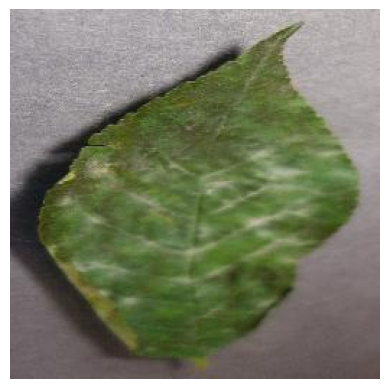


Symptoms: White powdery growth on leaves and fruit
Causes: Fungal infection (Podosphaera clandestina)
Solutions:
  - Apply sulfur-based fungicides
  - Prune to improve air circulation
  - Remove infected plant material
  - Use resistant varieties
  - Avoid overhead watering
Prevention: Proper spacing and regular monitoring


In [38]:
import glob
import cv2

def resolve_image_path(input_path, dataset_path):
    if os.path.isfile(input_path):
        return input_path
    #search in all subfolders
    matches = glob.glob(os.path.join(dataset_path, '*', input_path))
    if matches:
        return matches[0]
    return None

test_image_filename = '0a283423-3a6d-43a4-92e5-267c8153ca45___FREC_Pwd.M_4921.JPG'
test_image_path = resolve_image_path(test_image_filename, dataset_path)
print(f"Resolved test image path: {test_image_path}")

if test_image_path is None:
    raise FileNotFoundError(f"Image not found in dataset: {test_image_filename}")

img = cv2.imread(test_image_path)
if img is None:
    raise FileNotFoundError(f"Image not found or cannot be opened: {test_image_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, img_size)
img = img.astype(np.float32) / 255.0
img = np.expand_dims(img, axis=0)
prediction = model.predict(img)
class_idx = np.argmax(prediction[0])
confidence = prediction[0][class_idx]
predicted_class = class_names[class_idx]
print(f"Predicted Disease: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
plt.imshow(cv2.cvtColor(cv2.imread(test_image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Get solution
if predicted_class in disease_solutions:
    solution = disease_solutions[predicted_class]
    print(f"\nSymptoms: {solution['symptoms']}")
    print(f"Causes: {solution['causes']}")
    print(f"Solutions:")
    for sol in solution['solutions']:
        print(f"  - {sol}")
    print(f"Prevention: {solution['prevention']}")